# SMICA: Joint HI + Foreground Covariance Fit

Combines the two pieces built separately elsewhere in this repo into a single pipeline:

- **`SMICA_HI.ipynb`**: a *parametric* model for the HI angular power spectrum, $C^{HI}_\ell(\nu)$, built from a
  log-$\ell$ polynomial times a frequency-dependent trapezoidal basis, fit by maximum-likelihood spectral matching.
- **`smica_test.ipynb`**: a *blind, low-rank* model for the foreground frequency covariance,
  $R_{fg}(\ell) = F\,P_b(\ell)\,F^\top$ with $F$ a $(n_\nu \times r)$ mixing matrix, exploiting the fact that
  synchrotron + free-free are smooth and highly correlated across frequency.

Both notebooks previously treated the *other* component as truth (SMICA_HI used the true simulated
foreground covariance; smica_test used the true simulated HI covariance). Here both are **unknown and fit
jointly** in one spectral-matching maximum-likelihood step:

$$C_{\rm model}(\ell) = C_{\rm HI}(\ell;\,a) + C_{\rm noise}(\ell) + F\,P_b(\ell)\,F^\top$$

with only the noise covariance treated as known (theory noise). The joint parameter
vector is $\theta = (a,\,F,\,L_b)$ where $P_b = L_bL_b^\top$ enforces positive-semidefiniteness.

The true HI and foreground maps are still loaded below, but **only for validation plots** -- they never enter
the fit itself.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt
from scipy import optimize
from numpy.linalg import slogdet
from itertools import product
import sys
sys.path.append('../')

from scripts.compute_covariance import compute_covariance
from scripts.mask_maps import mask_maps
from scripts.compute_master import compute_master
from scripts.patch_mask import patch_mask

input_path = "/datadec/cppm/shoaib/SMICA_Paper/data"


In [2]:
nside = 256
npix = hp.nside2npix(nside)
# freqs = np.arange(544, 1088, step=10) 
freqs = np.arange(1042, 1183, step=1)  # MHz
nfreqs = len(freqs) - 1
lmax = 3 * nside - 1
ells = np.arange(2, lmax + 1)
almsize = hp.Alm.getsize(lmax)

r = 3            # foreground model rank
bin_width = 10   # ell bin width for pseudo-Cl binning
bins = 10        # number of frequency trapezoidal basis functions for the HI model


## Helper functions

In [3]:
def apply_mask_with_nan(data, mask):
    """Apply mask to data, setting masked regions (mask==0) to NaN for better visualization."""
    masked_data = data * mask
    masked_data[mask == 0] = np.nan
    return masked_data


def rotate_maps(map: np.ndarray) -> np.ndarray:
    """Convert maps frequency by frequency from galactic to celestial/equatorial coordinates."""
    rot = hp.rotator.Rotator(coord=['G', 'C'])
    rotated = np.zeros_like(map)
    for i in range(nfreqs):
        print(f"Rotating map {i+1}")
        rotated[i] = rot.rotate_map_alms(map[i])
    return rotated


def bin_spectra(cl, nside, delta):
    b = nmt.NmtBin.from_nside_linear(nside, nlb=delta)
    nbins = b.get_n_bands()
    leff = b.get_effective_ells()
    cl_binned = np.zeros((nbins, nfreqs, nfreqs))
    for i in range(nfreqs):
        for j in range(nfreqs):
            cl_binned[:, i, j] = b.bin_cell(cl[:, i, j])
    return leff, nbins, cl_binned


def normalize_covariance_by_sky_fraction(mask, fgds_cl, hi_cl, noise_cl, sky_cl):
    """Normalize covariance matrices by the sky fraction."""
    fsky = mask.mean()
    pseudo_fgds_cl = fgds_cl / fsky
    pseudo_hi_cl = hi_cl / fsky
    pseudo_noise_cl = noise_cl / fsky
    pseudo_sky_cl = sky_cl / fsky
    return fsky, pseudo_fgds_cl, pseudo_hi_cl, pseudo_noise_cl, pseudo_sky_cl


def build_trapezoidal_basis(freqs, n_bins, top_width=0.5):
    """Trapezoidal basis functions (___/----\\___) on the frequency grid.
        
    Parameters:
    - freqs: 1D array of frequency bin centers (nf,)
    - n_bins: number of trapezoidal functions (i.e., nq)
    - top_width: fraction of bin width used for the flat top (0 < top_width < 1)

    Returns:
    - phi: shape (n_bins, nf), the basis matrix
    """
    nf = len(freqs)
    vmin, vmax = freqs[0], freqs[-1]
    bin_edges = np.linspace(vmin, vmax, n_bins + 1)
    bwidth = bin_edges[1] - bin_edges[0]
    flat_top = top_width * bwidth
    slope_width = (1 - top_width) * bwidth / 2 #slope= 1/slope_width

    phi = np.zeros((n_bins, nf))
    for i in range(n_bins):
        # Define edges of the trapezoid
        left = bin_edges[i] - slope_width
        start_flat = bin_edges[i]
        end_flat = bin_edges[i + 1]
        right = bin_edges[i + 1] + slope_width
        for j, v in enumerate(freqs):
            if left <= v < start_flat:
                phi[i, j] = (v - left) / slope_width
            elif start_flat <= v <= end_flat:
                phi[i, j] = 1.0
            elif end_flat < v <= right:
                phi[i, j] = (right - v) / slope_width
            else:
                phi[i, j] = 0.0
    return phi


def pca_init(empirical, rank):
    """Initialize F, P_b for the rank-r foreground model from the top eigenvectors of the mean covariance.
    
    Parameters:
    ----------
    c_hat : np.ndarray
        Covariance matrix of shape (n_bins, n_freq, n_freq).
    
    r : int
        Number of principal components to retain.
    
    Returns:
    -------
    F : np.ndarray
        Matrix of shape (n_freq, r) containing the principal components.
    
    P_b : np.ndarray
        Matrix of shape (n_bins, r, r) containing the eigenvalues and eigenvectors.
    """
    R_global = np.mean(empirical, axis=0)
    
    #eigen decompositiom
    eigvals, eigvecs = np.linalg.eigh(R_global)  # ascending order
    #Take the top r eigenvectors:
    F_i = eigvecs[:, -rank:] # largest eigenvectors
    eigvals_r = np.clip(eigvals[-rank:], a_min=1e-15, a_max=None)
    P_b_i = np.array([np.diag(eigvals_r) for _ in range(empirical.shape[0])])
    for b in range(empirical.shape[0]):
         #projecting the empirical covariance into the subspace spanned by F.
        proj = F_i.T @ empirical[b] @ F_i
        P_b_i[b] = 0.5 * (proj + proj.T)
    return F_i, P_b_i


## Mask
Create a patch of sky near the south pole (same footprint used in both source notebooks).

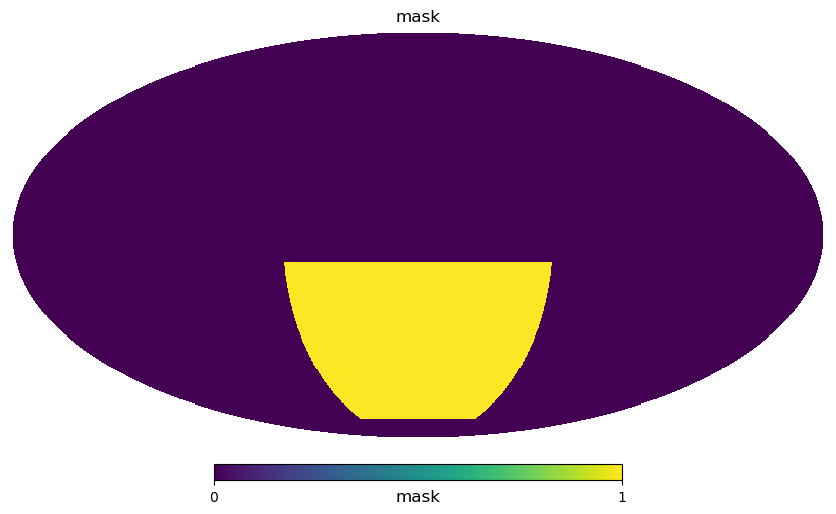

In [4]:
def create_sky_patch_mask(nside, ra_min, ra_max, dec_min, dec_max):
    """Create a rectangular sky patch mask in HEALPix format."""
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix), lonlat=False)
    ra = np.degrees(phi)
    dec = 90.0 - np.degrees(theta)
    ra = ((ra + 180) % 360) - 180
    mask = (
        (ra >= ra_min) & (ra <= ra_max) &
        (dec >= dec_min) & (dec <= dec_max)
    ).astype(np.uint8)
    return mask


mask = create_sky_patch_mask(nside=256, ra_min=-60.0, ra_max=60.0, dec_min=-75.0, dec_max=-10.0)
hp.mollview(mask, title="mask", unit="mask")

In [5]:
# mask = patch_mask(nside=256, ra_min=-60.0, ra_max=60.0, dec_min=-75.0, dec_max=-10.0,
#                    aposize=3.0, apotype='C1')
# hp.mollview(mask, title="mask", unit="mask")


## Load simulated maps

### 544-1088 MHz maps

In [6]:
# ff = np.load(f"{input_path}/smoothed_ff_maps.npy") * 1e-3     # mK
# sync = np.load(f"{input_path}/smoothed_sync_maps.npy") * 1e-3  # mK
# noise = np.load(f"{input_path}/noise_maps.npy")[:-1] * 1e3     # mK

# hi_cl2 = np.load(f"{input_path}/cal_hi_cov_mK.npy")
# cl_hi = np.transpose(hi_cl2, (2, 0, 1))
# hi_maps = np.load(f"{input_path}/hi_maps_mK.npy")

# fgds = (ff + sync)
# signal = fgds + hi_maps[:-1] + noise

### 1042-1183 MHz maps

In [7]:
# ff = np.load(f"{input_path}/UHF/ff_maps_mK.npy")     # mK
# sync = np.load(f"{input_path}/UHF/sync_maps_mK.npy")  # mK
# noise = np.load(f"{input_path}/UHF/noise_maps_1042_1183.npy")  *1e3    # mK

# hi_cl2 = np.load(f"{input_path}/UHF/hi_cl_mK.npy")
# cl_hi = np.transpose(hi_cl2, (2, 0, 1))
# hi_maps = np.load(f"{input_path}/UHF/hi_maps_mK_new.npy")

# #SCALE UP FGDS FOR ROBUSTENESS CHECK
# fgds = (ff + sync)
# signal = fgds + hi_maps + noise

## Rotate to equatorial coordinates

Rotating with alms (not pixel interpolation) avoids the resampling error that pixel-space rotation introduces.
The rotated maps are precomputed and cached, as in the source notebooks.

In [8]:
# rotated_fgds=rotate_maps(fgds)
# rotated_hi=rotate_maps(hi_maps)
# rotated_noise=rotate_maps(noise)
# rotated_sky= rotate_maps(signal)

In [9]:
# np.save("/datadec/cppm/shoaib/SMICA_Paper/data/UHF/rotated_fgds_1042_1183.npy", rotated_fgds)
# np.save("/datadec/cppm/shoaib/SMICA_Paper/data/UHF/rotated_hi_1042_1183.npy", rotated_hi)
# np.save("/datadec/cppm/shoaib/SMICA_Paper/data/UHF/rotated_noise_1042_1183.npy", rotated_noise)
# np.save("/datadec/cppm/shoaib/SMICA_Paper/data/UHF/rotated_sky_1042_1183.npy", rotated_sky)

In [10]:
rotated_fgds = np.load(f"{input_path}/UHF/rotated_fgds_1042_1183.npy")
rotated_hi = np.load(f"{input_path}/UHF/rotated_hi_1042_1183.npy")
rotated_noise = np.load(f"{input_path}/UHF/rotated_noise_1042_1183.npy")
rotated_sky = np.load(f"{input_path}/UHF/rotated_sky_1042_1183.npy")
"1042 - 1183MHz maps"

'1042 - 1183MHz maps'

## Mask maps and compute covariances

In [11]:
fgds_masked, _ = mask_maps(rotated_fgds, mask, almsize, lmax, nfreqs, npix)
hi_masked, _ = mask_maps(rotated_hi, mask, almsize, lmax, nfreqs, npix)
noise_masked, _= mask_maps(rotated_noise, mask, almsize, lmax, nfreqs, npix)
sky_masked, sky_alm = mask_maps(rotated_sky, mask, almsize, lmax, nfreqs, npix)


In [12]:
fgds_cl = compute_covariance(fgds_masked, lmax, almsize, nfreqs)
hi_cl_masked = compute_covariance(hi_masked, lmax, almsize, nfreqs)
noise_cl = compute_covariance(noise_masked, lmax, almsize, nfreqs)
sky_cl = compute_covariance(sky_masked, lmax, almsize, nfreqs)
fsky, pseudo_fgds_cl, pseudo_hi_cl, pseudo_noise_cl, pseudo_sky_cl = normalize_covariance_by_sky_fraction(
    mask, fgds_cl, hi_cl_masked, noise_cl, sky_cl
)


In [13]:
# _,_, dec_hi=compute_master(hi_masked, mask, True, delta_ell=10,nsides=nside, l_max=lmax, n_freq=nfreqs)
# _,_, dec_fgds=compute_master(fgds_masked, mask, True, delta_ell=10,nsides=nside, l_max=lmax, n_freq=nfreqs)
# _,_, dec_sky=compute_master(sky_masked, mask, True, delta_ell=10,nsides=nside, l_max=lmax, n_freq=nfreqs)
# leff, nbins, dec_noise=compute_master(noise_masked, mask, True, delta_ell=10,nsides=nside, l_max=lmax, n_freq=nfreqs)

In [14]:
# noise_binned=dec_noise
# hi_binned=dec_hi
# fgds_binned=dec_fgds
# sky_binned=dec_sky
# n_bins=nbins

In [15]:
ells.size

766

In [16]:
leff, n_bins, fgds_binned = bin_spectra(pseudo_fgds_cl, nside, bin_width)
*_, hi_binned = bin_spectra(pseudo_hi_cl, nside, bin_width)
*_, noise_binned = bin_spectra(pseudo_noise_cl, nside, bin_width)
*_, sky_binned = bin_spectra(pseudo_sky_cl, nside, bin_width)

# fgds_binned and hi_binned are the TRUE simulated covariances.
# They are used ONLY for validation plots below -- the joint fit never sees them.


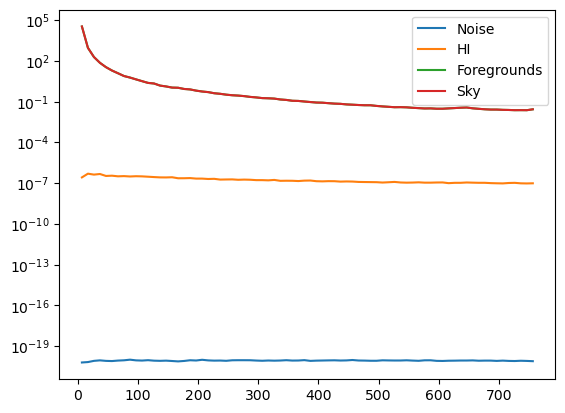

In [17]:
plt.plot(leff, noise_binned[:,100,100], label='Noise')
plt.plot(leff, hi_binned[:,100,100], label='HI')
plt.plot(leff, fgds_binned[:,100,100], label='Foregrounds')
plt.plot(leff, sky_binned[:,100,100], label='Sky')
plt.yscale('log')
plt.legend()

## Ensure the empirical (sky) covariance is PSD
Clip negative eigenvalues introduced by pseudo-$C_\ell$ mode-coupling / binning noise.

In [18]:
c_hat = np.zeros((n_bins, nfreqs, nfreqs))
for b in range(n_bins):
    cov = 0.5 * (sky_binned[b] + sky_binned[b].T)
    
    # Eigen-decomposition (since it's symmetric, use eigh)
    eigvals, eigvecs = np.linalg.eigh(cov)
    
    # Zero out negative eigenvalues
    eigvals_clipped = np.clip(eigvals, a_min=0, a_max=None)
    
    # Reconstruct the covariance matrix
    c_hat[b] = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T


## Part 1 -- Parametric HI covariance model

$$\log C^{HI}_{\ell}(\nu) = \sum_{p=0}^{P}\sum_{q=0}^{Q} a_{pq}\,(\log_{10}\ell)^p\,\Psi_q(\nu)$$

where $\Psi_q$ are power-law-scaled trapezoidal basis functions in frequency (`Model 5` from `SMICA_HI.ipynb`).
$a$ is diagonal-only in frequency -- no HI cross-frequency covariance is modeled at this stage.

In [19]:
P, Q = 5, bins - 1
v0 = freqs[23]
n_pow = 0.5

# Step 2: Log coordinates
log_ell = np.log10(leff)


# Step 3: Build hat-shaped basis
phi = build_trapezoidal_basis(freqs[:-1], bins)             # (bins, nfreqs)
scaling = (freqs[:-1] / v0) ** (-n_pow)                      # (nfreqs,)
# Unnormalized Psi: each row is φ_q(v) * scaling
Psi_unnorm = phi * scaling[None, :]
# Normalize across q (rows) for each v (column)
Psi = Psi_unnorm / Psi_unnorm.sum(axis=0, keepdims=True)     # (bins, nfreqs)


# Step 4: Build coeff matrix
basis_terms = list(product(range(P + 1), range(Q + 1)))# all (p, q) pairs (0,0), (0,1), ..., (P,Q)
n_a = len(basis_terms)
# total number of basis functions (P + 1) * (Q + 1)


def build_C_HI(a):
    """Diagonal-in-frequency parametric HI covariance model, shape (n_bins, nfreqs, nfreqs)."""
    a_mat = a.reshape((P + 1, Q + 1))
    log_C_diag = np.zeros((n_bins, nfreqs))
    for p in range(P + 1):
        for q in range(Q + 1):
            log_C_diag += a_mat[p, q] * np.outer(log_ell ** p, Psi[q])
    log_C_diag = np.clip(log_C_diag, -30, 30)  # keep exp() finite during line search
    C_diag = np.exp(log_C_diag)
    C_full = np.zeros((n_bins, nfreqs, nfreqs))
    for b in range(n_bins):
        np.fill_diagonal(C_full[b], C_diag[b])
    return C_full


### Initial guess for the HI parameters

Seeded from a least-squares fit of the log-covariance to the **true** simulated HI spectrum -- this is a
simulation-only convenience to give the optimizer a fast, well-conditioned starting point. It does not enter
the joint likelihood below, which only ever sees `sky_binned` (`c_hat`) and the known noise covariance. A
real (non-simulation) pipeline would instead seed `a0` from a smooth power-law guess.

In [20]:
X_log = np.zeros((n_bins * nfreqs, n_a))
for i, (p, q) in enumerate(basis_terms):
    # Outer product: (nell,) x (nf,) → shape (nell, nf)
    X_log[:, i] = np.outer(log_ell ** p, Psi[q]).reshape(-1)

log_hi_target = np.log(np.maximum(np.array([np.diag(hi_binned[b]) for b in range(n_bins)]), 1e-30)).reshape(-1)

# Step 5: Solve least mean squares
a0, *_ = np.linalg.lstsq(X_log, log_hi_target, rcond=None)

print("HI init cost check -- max|log C_fit - log hi_target|:",
      np.max(np.abs(X_log @ a0 - log_hi_target)))

C_HI_init = build_C_HI(a0)


HI init cost check -- max|log C_fit - log hi_target|: 0.8208145030760097


## Part 2 -- Blind rank-r foreground covariance model

$$R_{fg}(\ell) = F\,P_b(\ell)\,F^\top, \qquad P_b = L_bL_b^\top \text{ (PSD by construction)}$$

$F$ (shape $n_\nu \times r$) is left fully free, matching `smica_test.ipynb`'s approach.

Initialized via PCA directly on `c_hat` (matching `smica_test.ipynb`), not on a residual with the HI guess
subtracted off. Subtracting `C_HI_init` first sounds more principled, but at these frequencies the
foregrounds outweigh HI by 7-12 orders of magnitude (compare the y-axes of the two recovery plots below) --
so `c_hat` is *already* essentially pure foreground+noise , and the subtraction step
was doing nothing except adding a dependency on the HI initial guess.

In [21]:
F0, P_b0 = pca_init(c_hat, r)

L_b0 = np.zeros_like(P_b0) #for PSD
eps = 1e-10
for b in range(n_bins):
    P_sym = 0.5 * (P_b0[b] + P_b0[b].T)
    P_sym += eps * np.trace(P_sym) / r * np.eye(r) if np.trace(P_sym) > 0 else eps * np.eye(r)
    try:
        L_b0[b] = np.linalg.cholesky(P_sym)
    except np.linalg.LinAlgError:
        eigval, eigvec = np.linalg.eigh(P_sym)
        P_psd = eigvec @ np.diag(np.clip(eigval, 1e-12, None)) @ eigvec.T
        L_b0[b] = np.linalg.cholesky(P_psd)


## Part 3 -- Joint SMICA fit

Single spectral-matching maximum-likelihood fit over $\theta = (a,\,F,\,L_b)$:

$$\mathcal{L}(\theta) = \sum_b \mathrm{tr}\!\big(\hat C_b R_b^{-1}\big) - \log\det\!\big(\hat C_b R_b^{-1}\big) - n_\nu,
\qquad R_b = C_{\rm HI}(\ell_b;a) + C_{\rm noise}(\ell_b) + F P_b(\ell_b) F^\top$$

The gradient reuses the same $\Delta_b = R_b^{-1} - R_b^{-1}\hat C_b R_b^{-1}$ factor for every parameter
block (HI, $F$, $L_b$) -- it is the common building block of the SMICA mismatch gradient, matching the
per-block derivations already used separately in `SMICA_HI.ipynb` and `smica_test.ipynb`.

In [22]:
n_F = nfreqs * r
n_L = n_bins * r * r
n_params = n_a + n_F + n_L

#FIXED
b_bins = nmt.NmtBin.from_nside_linear(nside, nlb=bin_width)
n_b = fsky * np.array([sum(2*l + 1 for l in b_bins.get_ell_list(b)) for b in range(n_bins)])
n_b = n_b / n_b.mean()   # keep relative bin-to-bin weighting, remove the overall scale shift


def unpack(theta):
    a = theta[:n_a]
    F = theta[n_a:n_a + n_F].reshape(nfreqs, r)
    L_b = theta[n_a + n_F:].reshape(n_bins, r, r)
    P_b = np.einsum('bij,bkj->bik', L_b, L_b)
    return a, F, L_b, P_b


def pack(a, F, L_b):
    return np.concatenate([a.flatten(), F.flatten(), L_b.flatten()])


scale = np.linalg.norm(c_hat)  # purely empirical conditioning factor, no true info

# # The lowest 1-2 ell bins are poorly conditioned for a compact/sharp-edged
# # patch (few independent modes, large mode-mixing correction) -- excluding
# # them keeps one badly-estimated bin from dominating the shared-F joint fit.
# fit_bins = range(2, n_bins)


def build_C_total(theta):
    a, F, L_b, P_b = unpack(theta)
    C_hi = build_C_HI(a)
    C_fg = np.einsum('ir,brs,js->bij', F, P_b, F)
    return C_hi, C_fg, C_hi + noise_binned + C_fg


def joint_smica_loss(theta):
    _, _, C_model = build_C_total(theta)
    loss = 0.0
    for b in range(n_bins):
        R = C_model[b] / scale
        Chat = c_hat[b] / scale
        Rinv = np.linalg.inv(R)
        _, logdet = slogdet(Chat @ Rinv)
        loss += n_b[b] * (np.trace(Chat @ Rinv) - logdet - nfreqs)
    return loss


def joint_smica_jacobian(theta):
    a, F, L_b, P_b = unpack(theta)
    C_hi = build_C_HI(a)
    C_fg = np.einsum('ir,brs,js->bij', F, P_b, F)
    C_model = C_hi + noise_binned + C_fg

    grad_a = np.zeros((P + 1, Q + 1))
    grad_F = np.zeros_like(F)
    grad_L = np.zeros_like(L_b)

    for b in range(n_bins):
        R = C_model[b] / scale
        Chat = c_hat[b] / scale
        Rinv = np.linalg.inv(R)
        Delta = n_b[b]*(Rinv - Rinv @ Chat @ Rinv)

        # -- HI block --
        C_diag_b = np.diag(C_hi[b])
        for p in range(P + 1):
            for q in range(Q + 1):
                dR = np.zeros((nfreqs, nfreqs))
                np.fill_diagonal(dR, C_diag_b * (log_ell[b] ** p) * Psi[q])
                grad_a[p, q] += np.trace(Delta @ dR) / scale

        # -- foreground block --
        # d/dF
        grad_F += 2 * Delta @ (F @ P_b[b]) / scale
        # d/dP
        Gp = F.T @ Delta @ F
        # chain rule through Cholesky
        grad_L[b] = 2 * (Gp @ L_b[b]) / scale

    return pack(grad_a, grad_F, grad_L)


In [23]:
theta0 = pack(a0, F0, L_b0)
print("n_params:", n_params, "(HI:", n_a, ", F:", n_F, ", L:", n_L, ")")
print("Initial joint SMICA cost:", joint_smica_loss(theta0))
print("Initial joint grad norm:", np.linalg.norm(joint_smica_jacobian(theta0)))


n_params: 1164 (HI: 60 , F: 420 , L: 684 )


Initial joint SMICA cost: 665.3835755377897
Initial joint grad norm: 84777.98644427798


In [24]:
res = optimize.minimize(
    joint_smica_loss, theta0,
    jac=joint_smica_jacobian,
    method='L-BFGS-B',
    options={'disp': True, 'maxiter': 5000, 'maxfun': 200000, 'maxls': 200,
             'ftol': 1e-12, 'gtol': 1e-7}
)
print(res.message, '| nit:', res.nit, '| fun:', res.fun)


/tmp/ipykernel_221221/2376949914.py:1: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = optimize.minimize(


CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH | nit: 14 | fun: 665.0392197014271


In [25]:
from pprint import pprint

pprint(res)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 665.0392197014271
        x: [-1.584e+01 -1.867e+01 ... -7.184e-01  1.998e+00]
      nit: 14
      jac: [ 1.225e+01  9.557e-01 ...  4.553e-03  2.128e-03]
     nfev: 400
     njev: 400
 hess_inv: <1164x1164 LbfgsInvHessProduct with dtype=float64>


In [27]:
np.linalg.norm(res.jac)/np.linalg.norm(joint_smica_jacobian(theta0))*100

np.float64(46.47017100347555)

In [28]:
theta_hat = res.x
a_hat, F_hat, L_hat, P_b_hat = unpack(theta_hat)
C_HI_fit, C_FG_fit, C_total_fit = build_C_total(theta_hat)

def is_psd(mats, tol=0):
    return all(np.all(np.linalg.eigvalsh(m) >= -tol) for m in mats)

print("Fitted total covariance PSD:", is_psd(C_total_fit))
print("Fitted foreground P_b PSD:", is_psd(P_b_hat))


Fitted total covariance PSD: True
Fitted foreground P_b PSD: True


$$C_{HI}(\ell)\to \text{apply } W_{HI}(\ell)=C_{HI}(\ell)R(\ell)^{-1}\text{ to thed actual } a_{\rm data}(\ell,m,\nu) \to \text{reconstructed HI map} \to \text{grid} \to P(k)$$

In [33]:
W_HI = np.zeros((n_bins, nfreqs, nfreqs))
W_FG = np.zeros((n_bins, nfreqs, nfreqs))
for b in range(n_bins):
    Rinv = np.linalg.inv(C_total_fit[b])
    W_HI[b] = C_HI_fit[b] @ Rinv
    W_FG[b] = C_FG_fit[b] @ Rinv


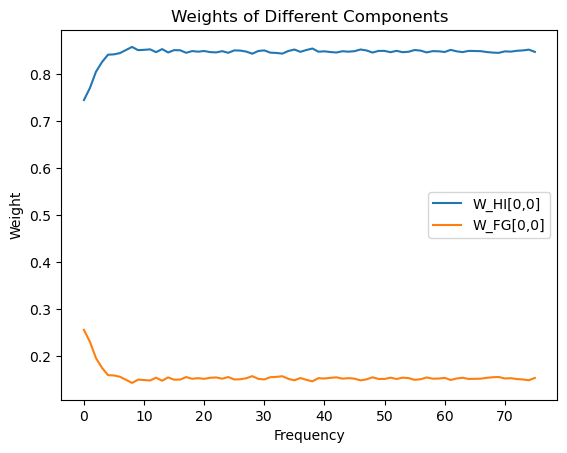

In [34]:
plt.plot(W_HI[:,0, 0], label="W_HI[0,0]")
plt.plot(W_FG[:,0, 0], label="W_FG[0,0]")
plt.xlabel("Frequency")
plt.ylabel("Weight")
plt.title("Weights of Different Components")
plt.legend()
plt.show()

In [36]:
# Apply the per-bin Wiener filters to the observed-data alms, ell by ell. 
b_nmt = nmt.NmtBin.from_lmax_linear(lmax, nlb=bin_width)

alm_HI = np.zeros_like(sky_alm)
alm_FG = np.zeros_like(sky_alm)

for b in range(n_bins):
    for l in b_nmt.get_ell_list(b):
        idx = hp.Alm.getidx(lmax, l, np.arange(l + 1))
        alm_HI[:, idx] = W_HI[b] @ sky_alm[:, idx]
        alm_FG[:, idx] = W_FG[b] @ sky_alm[:, idx]

# NmtBin.from_lmax_linear only bins up through its last full bin (761 here for
# lmax=767, nlb=10) -- the remaining few multipoles up to lmax were previously
# left at zero. Reuse the last bin's filter for them instead of dropping them.
last_covered_ell = b_nmt.get_ell_list(n_bins - 1)[-1]
for l in range(lmax + 1):
    idx = hp.Alm.getidx(lmax, l, np.arange(l + 1))
    alm_HI[:, idx] = W_HI[n_bins - 1] @ sky_alm[:, idx]
    alm_FG[:, idx] = W_FG[n_bins - 1] @ sky_alm[:, idx]


In [37]:
# Inverse-spherical harmoic transform each frequency channel back to a HEALPix map, then save for regridding /
# for P(k) comparison in gridimp_cartesian_cube.ipynb.
#what was the niter thingy simon once mentioned for transforms?
hi_recovered = np.zeros((nfreqs, npix))
fg_recovered = np.zeros((nfreqs, npix))
for nf in range(nfreqs):
    hi_recovered[nf] = hp.alm2map(alm_HI[nf], nside, lmax=lmax)
    fg_recovered[nf] = hp.alm2map(alm_FG[nf], nside, lmax=lmax)

patch = mask.astype(bool)
print(f"HI recovered std (patch) = {np.std(hi_recovered[:, patch]):.4g} mK")
print(f"HI truth std (patch)     = {np.std(hi_masked[:, patch]):.4g} mK")

print("---------------------------")
print(f"FG recovered std (patch) = {np.std(fg_recovered[:, patch]):.4g} mK")
print(f"FG truth std (patch)     = {np.std(fgds_masked[:, patch]):.4g} mK")

# np.save(f"{input_path}/hi_recovered.npy", hi_recovered)
# np.save(f"{input_path}/fg_recovered.npy", fg_recovered)
# print("Saved recovered HI/FG maps:", hi_recovered.shape)


HI recovered std (patch) = 0.09372 mK
HI truth std (patch)     = 0.09282 mK
---------------------------
FG recovered std (patch) = 225.3 mK
FG truth std (patch)     = 225.4 mK


In [ ]:
# np.save(f"{input_path}/UHF/hi_smica_recovered_1042_1183.npy", hi_recovered)
# np.save(f"{input_path}/UHF/fg_smica_recovered_1042_1183.npy", fg_recovered)
# print("Saved recovered HI/FG maps:", hi_recovered.shape, fg_recovered.shape)

Saved recovered HI/FG maps: (140, 786432) (140, 786432)


### Updated these plots by asking copilot how to make the residual plot present better+ colorbar with centre at zero

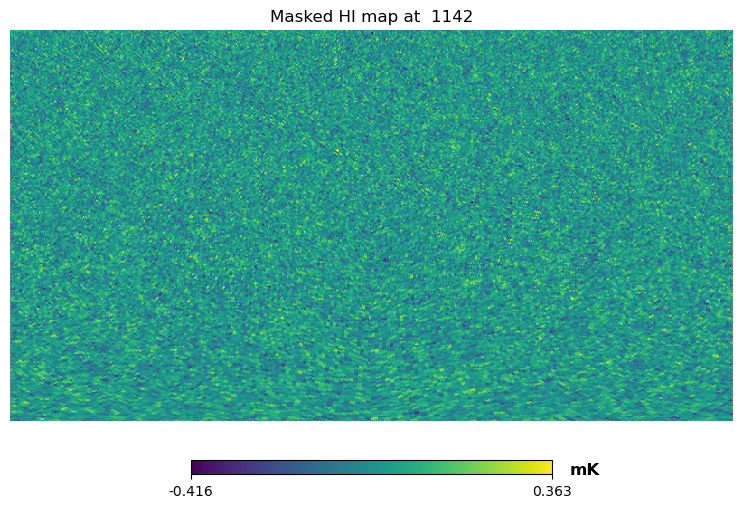

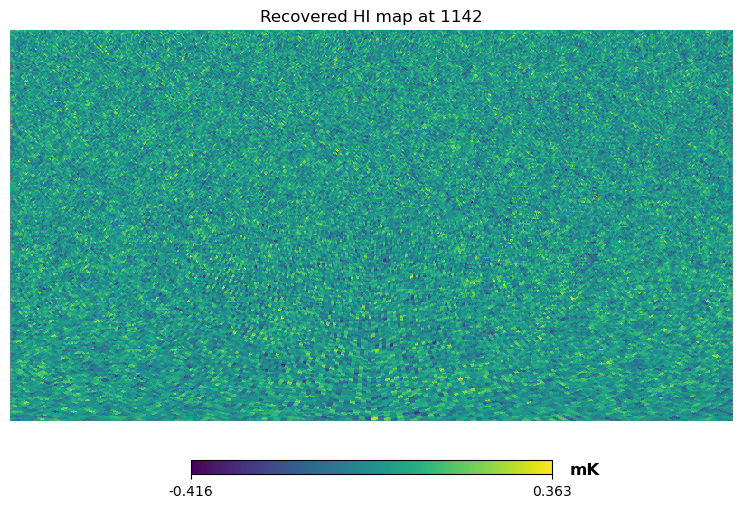

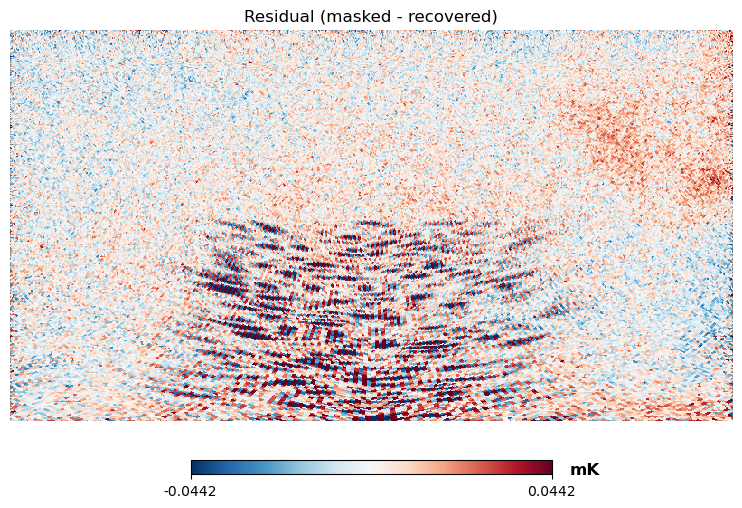

In [52]:
f=100
hi_masked_nan = apply_mask_with_nan(hi_masked[f], mask)
hi_recovered_nan = apply_mask_with_nan(hi_recovered[f], mask)
vmin, vmax = np.nanmin(hi_masked_nan), np.nanmax(hi_masked_nan)

lonra, latra = [-60, 60], [-75, -10]  # patch bounds, matches create_sky_patch_mask above

hp.cartview(hi_masked_nan, lonra=lonra, latra=latra, title=f"Masked HI map at  {freqs[f]}", unit="mK", min=vmin, max=vmax)
hp.cartview(hi_recovered_nan, lonra=lonra, latra=latra, title=f"Recovered HI map at {freqs[f]}", unit="mK", min=vmin, max=vmax)

residual = hi_masked_nan - hi_recovered_nan
vabs = np.nanpercentile(np.abs(residual), 99)
hp.cartview(residual, lonra=lonra, latra=latra, title="Residual (masked - recovered)", unit="mK", cmap='RdBu_r', min=-vabs, max=vabs)

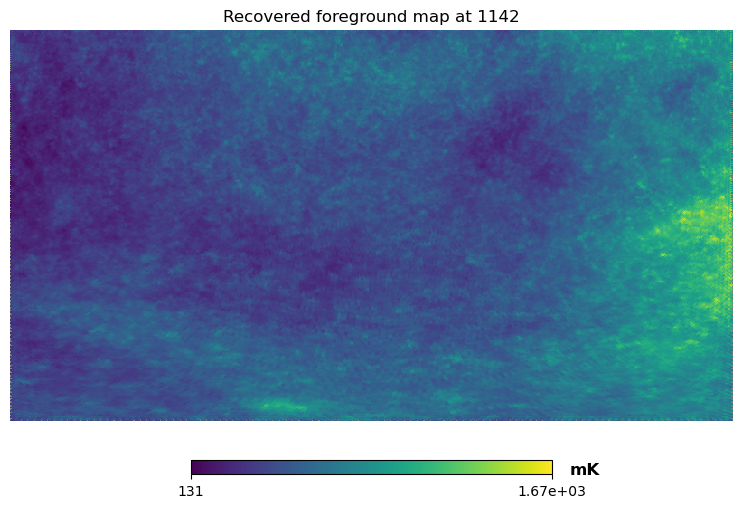

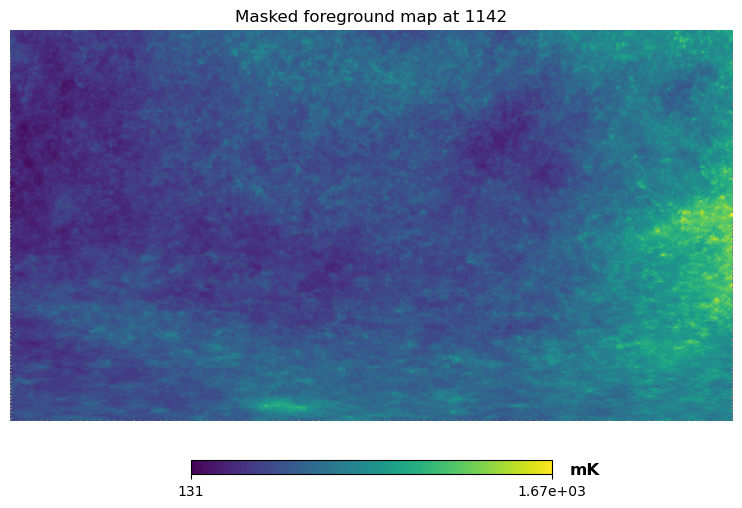

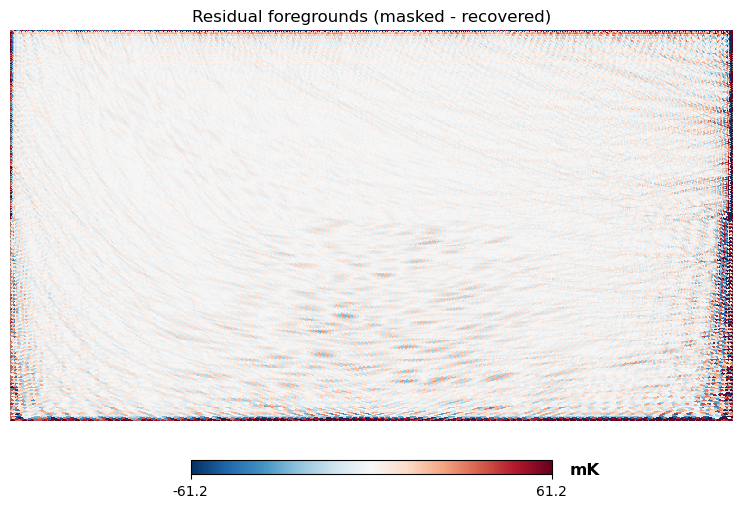

In [50]:
fgds_masked_nan = apply_mask_with_nan(fgds_masked[f], mask)
fgds_recovered_nan = apply_mask_with_nan(fg_recovered[f], mask)
vmin, vmax = np.nanmin(fgds_masked_nan), np.nanmax(fgds_masked_nan)

lonra, latra = [-60, 60], [-75, -10]  # patch bounds, matches create_sky_patch_mask above

hp.cartview(fgds_recovered_nan, lonra=lonra, latra=latra, title=f"Recovered foreground map at {freqs[f]}", unit="mK", min=vmin, max=vmax)
hp.cartview(fgds_masked_nan, lonra=lonra, latra=latra, title=f"Masked foreground map at {freqs[f]}", unit="mK", min=vmin, max=vmax)

residual_fg = fgds_masked_nan - fgds_recovered_nan
vabs = np.nanpercentile(np.abs(residual_fg), 99)
hp.cartview(residual_fg, lonra=lonra, latra=latra, title="Residual foregrounds (masked - recovered)", unit="mK", cmap='RdBu_r', min=-vabs, max=vabs)

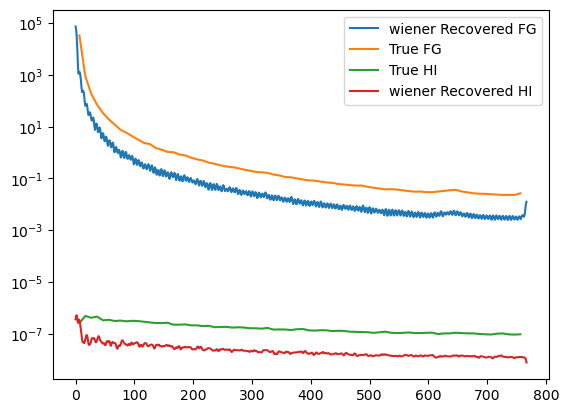

In [42]:
fg_w=hp.anafast(fg_recovered[f])
hi_w=hp.anafast(hi_recovered[f])
plt.plot(fg_w, label="wiener Recovered FG")
plt.plot(leff, fgds_binned[:, f, f], label="True FG")
plt.plot(leff, hi_binned[:, f, f], label="True HI")
plt.plot(hi_w, label="wiener Recovered HI")
plt.yscale('log')
plt.legend()

## Recovery diagnostics

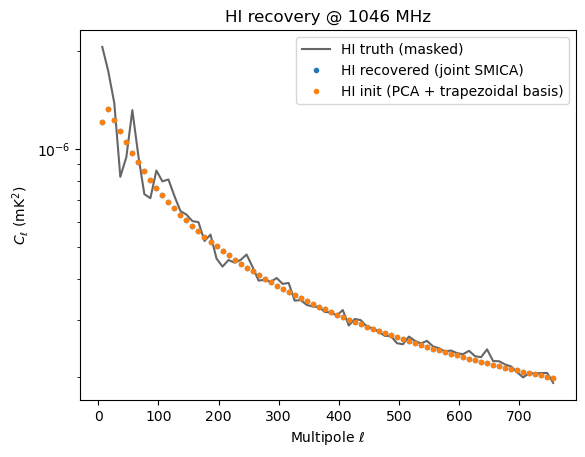

In [43]:
f = 4 # frequency channel index to inspect

plt.figure()
plt.plot(leff, hi_binned[:, f, f], 'k-', alpha=0.6, label='HI truth (masked)')
plt.plot(leff, C_HI_fit[:, f, f], '.', label='HI recovered (joint SMICA)')
plt.plot(leff, C_HI_init[:, f, f], '.', label='HI init (PCA + trapezoidal basis)')
plt.yscale('log')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell$ (mK$^2$)')
plt.title(f'HI recovery @ {freqs[f]} MHz')
plt.legend()
plt.show()


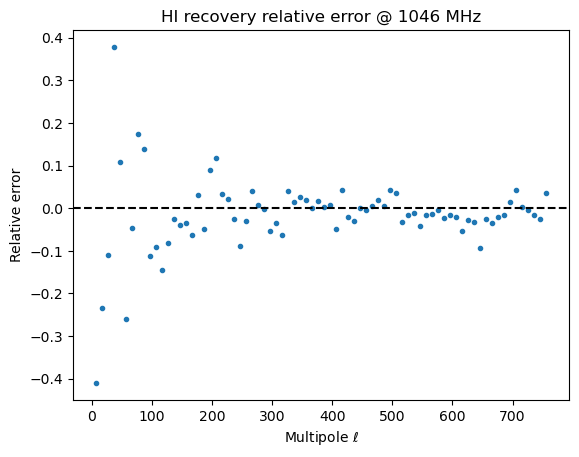

In [44]:
plt.figure()
plt.plot(leff, (C_HI_fit[:, f, f] - hi_binned[:, f, f]) / hi_binned[:, f, f], '.')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel('Relative error')
plt.title(f'HI recovery relative error @ {freqs[f]} MHz')
plt.show()


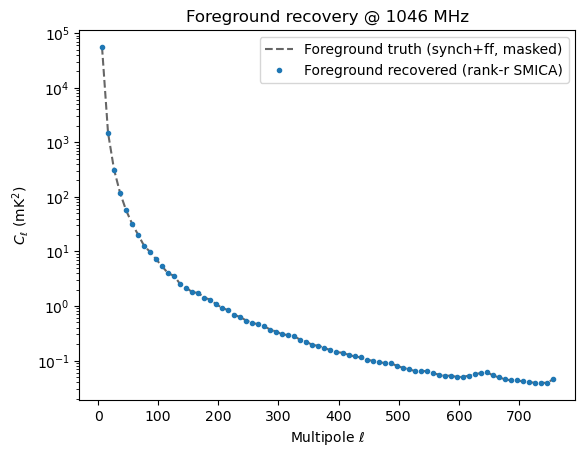

In [45]:
plt.figure()
plt.plot(leff, fgds_binned[:, f, f], 'k--', alpha=0.6, label='Foreground truth (synch+ff, masked)')
plt.plot(leff, C_FG_fit[:, f, f], '.', label='Foreground recovered (rank-r SMICA)')
plt.yscale('log')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell$ (mK$^2$)')
plt.title(f'Foreground recovery @ {freqs[f]} MHz')
plt.legend()
plt.show()


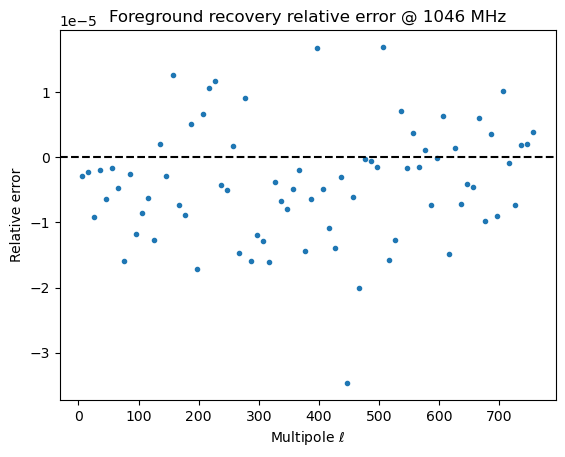

In [46]:
plt.figure()
plt.plot(leff, (C_FG_fit[:, f, f] - fgds_binned[:, f, f])/ fgds_binned[:, f, f], '.')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel('Relative error')
plt.title(f'Foreground recovery relative error @ {freqs[f]} MHz')
plt.show()


## copied from thesis code

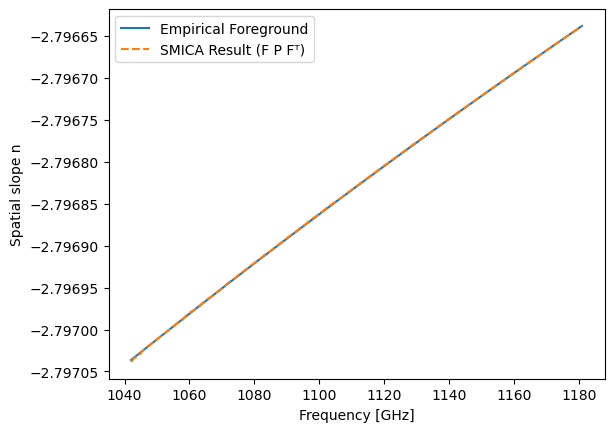

In [47]:
from scipy.stats import linregress

logs = np.log(leff)
powers_fg = []
powers_model = []
intercept_fg = []
intercept_model = []

for i in range(nfreqs):
    y_fg = np.log(fgds_binned[:,i,i])
    y_model = np.log(np.abs(C_FG_fit[:,i,i]))

    slope_fg,int_fg,*_ = linregress(logs, y_fg)
    slope_model,int_model,*_ = linregress(logs, y_model)

    powers_fg.append(slope_fg)
    powers_model.append(slope_model)
    
    intercept_fg.append(int_fg)
    intercept_model.append(int_model)
plt.plot(freqs[:-1],powers_fg, label='Empirical Foreground')
plt.plot(freqs[:-1],powers_model, '--', label='SMICA Result (F P Fᵀ)')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Spatial slope n')
plt.legend()

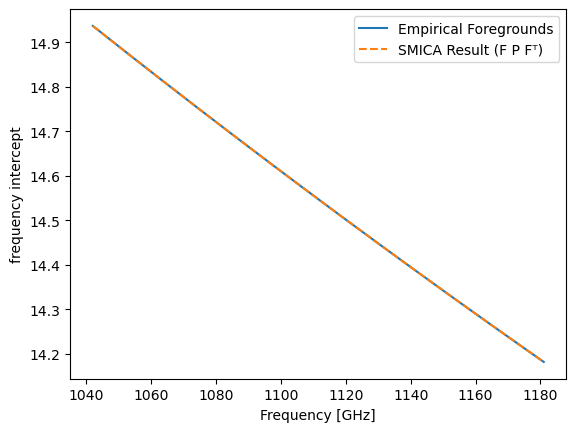

In [48]:
plt.plot(freqs[:-1],intercept_fg, label='Empirical Foregrounds')
plt.plot(freqs[:-1],intercept_model, '--', label='SMICA Result (F P Fᵀ)')
plt.xlabel('Frequency [GHz]')
plt.ylabel('frequency intercept')
plt.legend()

# -------EXTRA----------

## HI parameter error bars

Fisher information for the HI block $a$, with the foreground and noise covariances fixed at their joint
best-fit values (i.e. these error bars do not yet marginalize over foreground/HI degeneracy -- they answer
"how well is $a$ constrained given the fitted foreground shape", matching the error-bar treatment already
used in `SMICA_HI.ipynb`, just with `C_FG_fit` in place of the oracle `fgds_binned`).

In [106]:
F_fisher = np.zeros((n_a, n_a))
for b in range(n_bins):
    M_inv = np.linalg.inv(C_total_fit[b])
    C_diag_b = np.diag(C_HI_fit[b])
    dRs = [np.diag(C_diag_b * (log_ell[b] ** p) * Psi[q]) for p, q in basis_terms]
    for m in range(n_a):
        A = M_inv @ dRs[m] @ M_inv
        for k in range(m, n_a):
            val = 0.5 * np.trace(A @ dRs[k])
            F_fisher[m, k] += val
            if k != m:
                F_fisher[k, m] += val

Sigma_a = np.linalg.inv(F_fisher)

sigma_C_HI = np.zeros((n_bins, nfreqs))
for b in range(n_bins):
    for v in range(nfreqs):
        J = np.array([log_ell[b] ** p * Psi[q, v] for p, q in basis_terms])
        sigma_C_HI[b, v] = C_HI_fit[b, v, v] * np.sqrt(J @ Sigma_a @ J)


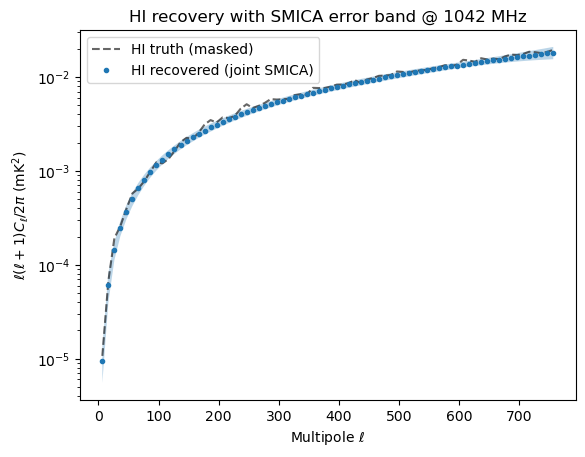

In [107]:
factor = leff * (leff + 1) / (2 * np.pi)
C_hi_d = factor * C_HI_fit[:, f, f]
C_hi_true_d = factor * hi_binned[:, f, f]
sigma_d = factor * sigma_C_HI[:, f]

fig, ax = plt.subplots()
ax.plot(leff, C_hi_true_d, 'k--', alpha=0.6, label='HI truth (masked)')
ax.plot(leff, C_hi_d, '.', label='HI recovered (joint SMICA)')
ax.fill_between(leff, C_hi_d - sigma_d, C_hi_d + sigma_d, alpha=0.3)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi$ (mK$^2$)')
ax.set_title(f'HI recovery with SMICA error band @ {freqs[f]} MHz')
ax.set_yscale('log')
ax.legend()
plt.show()


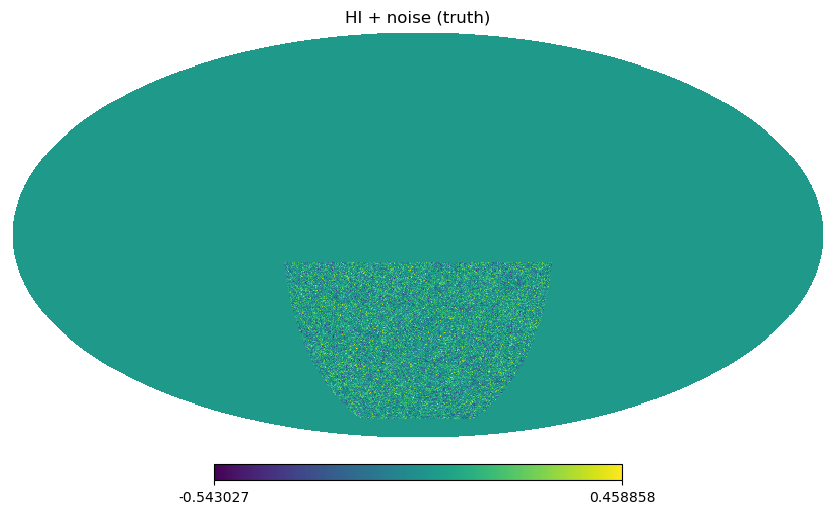

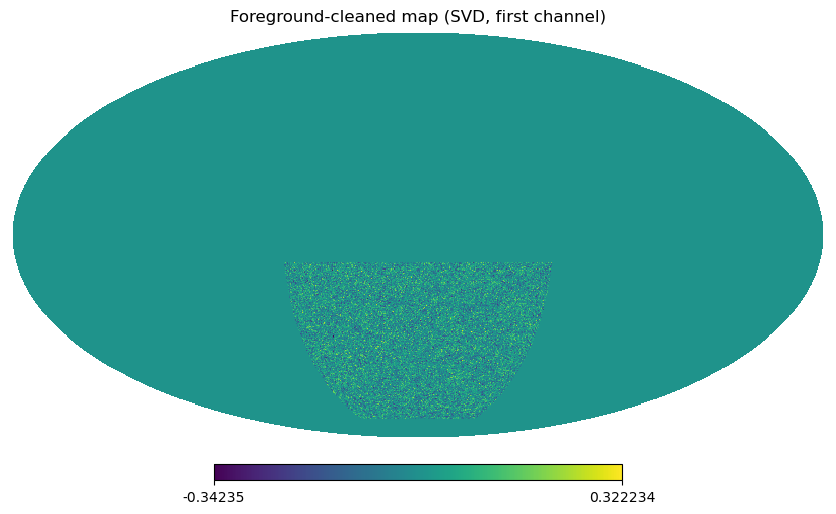

In [108]:
cube_clean = sky_masked - np.mean(sky_masked, axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(cube_clean, full_matrices=False)
n_modes = r
cube_fg_removed = cube_clean - (U[:, :n_modes] @ np.diag(S[:n_modes]) @ Vt[:n_modes, :])

hp.mollview(hi_masked[0] + noise_masked[0], title="HI + noise (truth)")
hp.mollview(cube_fg_removed[0], title="Foreground-cleaned map (SVD, first channel)")
